# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) — UNSW-NB15 Dataset
### Binary Classification: Normal (0) vs Attack (1)

---
**Dataset:** UNSW-NB15 subset | 40,000 training samples | 10,000 testing samples  
**Features:** 15 network flow features + 1 target label  
**Models:** Logistic Regression, Naive Bayes, KNN, SVM, Decision Tree, Random Forest, Gradient Boosting, Deep Neural Network

---
## Section 0 — Imports & Setup

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    confusion_matrix, classification_report,
    precision_recall_curve, auc, roc_auc_score
)

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All libraries imported successfully.')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   scikit-learn version: ', end='')
import sklearn; print(sklearn.__version__)

✅ All libraries imported successfully.
   TensorFlow version : 2.19.0
   scikit-learn version: 1.6.1


---
## Section 1 — Load Data

In [2]:
# ── FILE PATHS ────────────────────────────────────────────────────────────────
# If running on Google Colab, upload the CSV files when prompted.
# If running locally, place the CSV files in the same folder as this notebook.

import os

TRAIN_PATH = 'UNSW_NB15_train_40k.csv'
TEST_PATH  = 'UNSW_NB15_test_10k.csv'

# ── Colab auto-upload (only runs inside Colab) ────────────────────────────────
try:
    from google.colab import files
    if not os.path.exists(TRAIN_PATH):
        print('Upload UNSW_NB15_train_40k.csv')
        files.upload()
    if not os.path.exists(TEST_PATH):
        print('Upload UNSW_NB15_test_10k.csv')
        files.upload()
except ImportError:
    pass   # Not in Colab — use local files

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Training set : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'Testing  set : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
train_df.head()

Upload UNSW_NB15_train_40k.csv


Saving UNSW_NB15_train_40k.csv to UNSW_NB15_train_40k.csv
Upload UNSW_NB15_test_10k.csv


Saving UNSW_NB15_test_10k.csv to UNSW_NB15_test_10k.csv
Training set : 40,000 rows × 16 columns
Testing  set : 10,000 rows × 16 columns


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


---
## Section 2 — Exploratory Data Analysis (EDA)

In [3]:
# ── 2.1  Basic Info ──────────────────────────────────────────────────────────
print('=== Data Types & Non-Null Counts ===')
print(train_df.info())
print('\n=== Statistical Summary ===')
train_df.describe(include='all').T

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   proto    40000 non-null  object 
 1   state    40000 non-null  object 
 2   service  40000 non-null  object 
 3   dur      40000 non-null  float64
 4   sbytes   40000 non-null  int64  
 5   dbytes   40000 non-null  int64  
 6   spkts    40000 non-null  int64  
 7   dpkts    40000 non-null  int64  
 8   sload    40000 non-null  float64
 9   dload    40000 non-null  float64
 10  sttl     40000 non-null  int64  
 11  dttl     40000 non-null  int64  
 12  smean    40000 non-null  int64  
 13  dmean    40000 non-null  int64  
 14  sinpkt   40000 non-null  float64
 15  label    40000 non-null  int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 4.9+ MB
None

=== Statistical Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
proto,40000,133,tcp,23683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,40000,7,FIN,22666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,40000,13,-,24068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dur,40000.0,NaN,NaN,NaN,1.18155,5.715719,0.0,0.00001,0.026797,0.647432,59.999989
sbytes,40000.0,NaN,NaN,NaN,6409.099025,125252.505243,46.0,146.0,810.0,2558.0,12029826.0
dbytes,40000.0,NaN,NaN,NaN,24713.269875,170838.115164,0.0,0.0,320.0,3380.0,14655550.0
spkts,40000.0,NaN,NaN,NaN,26.478525,106.980146,1.0,2.0,10.0,22.0,9094.0
dpkts,40000.0,NaN,NaN,NaN,30.275575,129.778977,0.0,0.0,6.0,22.0,10974.0
sload,40000.0,NaN,NaN,NaN,45729073.105196,175004052.891331,0.0,12442.756102,517928.3125,4667234.5,5988000256.0
dload,40000.0,NaN,NaN,NaN,1471366.13003,3451494.048964,0.0,0.0,15074.69141,687258.6875,22353024.0


In [4]:
# ── 2.2  Missing Values ──────────────────────────────────────────────────────
missing = train_df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '  → None found ✅')

Missing values per column:
  → None found ✅


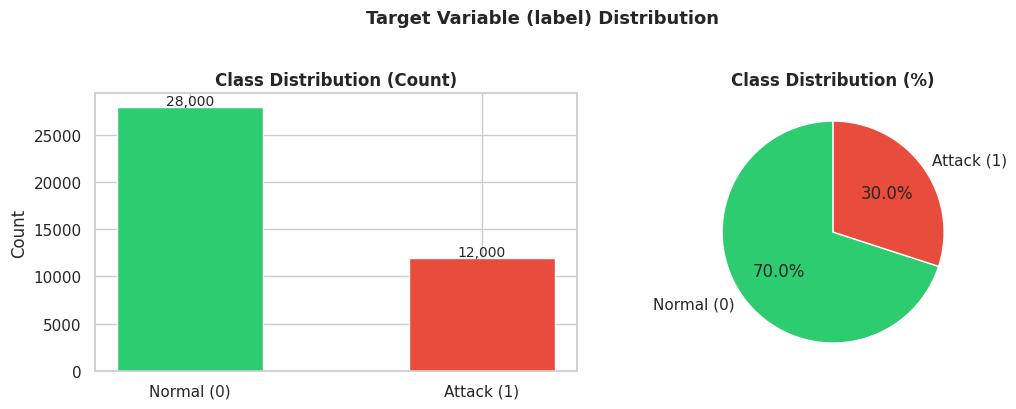


Normal  (0): 28,000  (70.0%)
Attack  (1): 12,000  (30.0%)
Imbalance Ratio: 2.33x → SMOTE will be applied


In [5]:
# ── 2.3  Class Distribution ──────────────────────────────────────────────────
counts = train_df['label'].value_counts()
labels = ['Normal (0)', 'Attack (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable (label) Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nNormal  (0): {counts[0]:,}  ({counts[0]/len(train_df)*100:.1f}%)')
print(f'Attack  (1): {counts[1]:,}  ({counts[1]/len(train_df)*100:.1f}%)')
imbalance_ratio = counts.max() / counts.min()
print(f'Imbalance Ratio: {imbalance_ratio:.2f}x → {"SMOTE will be applied" if imbalance_ratio > 1.5 else "Balanced"}')

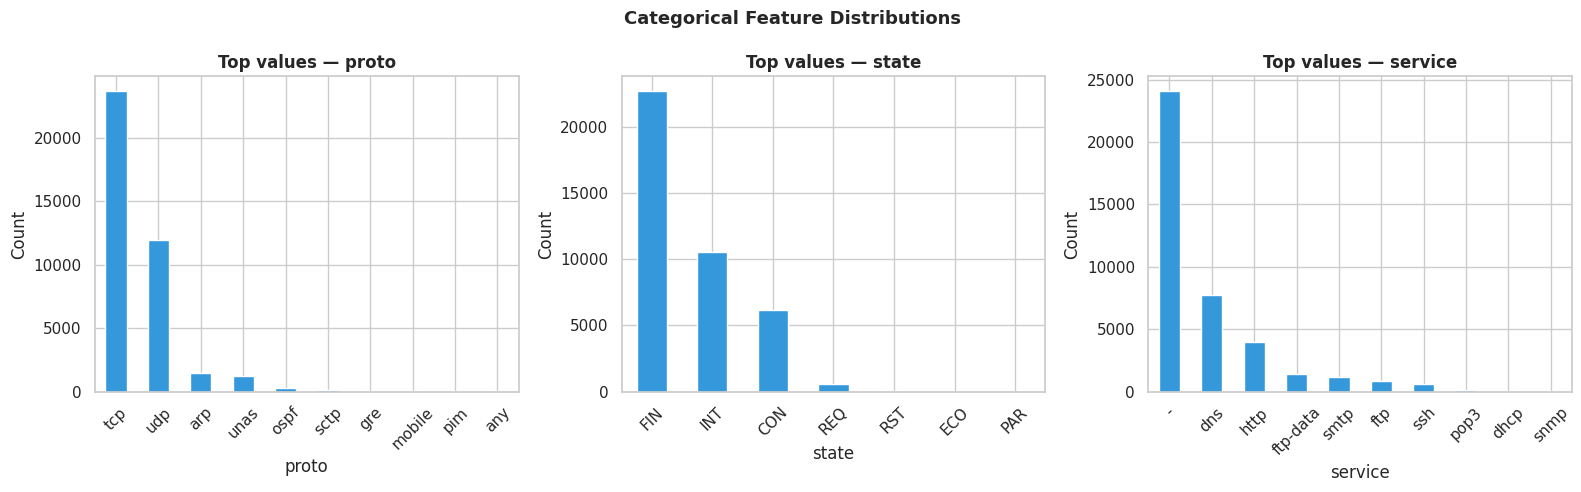

In [6]:
# ── 2.4  Categorical Feature Analysis ────────────────────────────────────────
cat_cols = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    vc = train_df[col].value_counts().head(10)
    vc.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Top values — {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

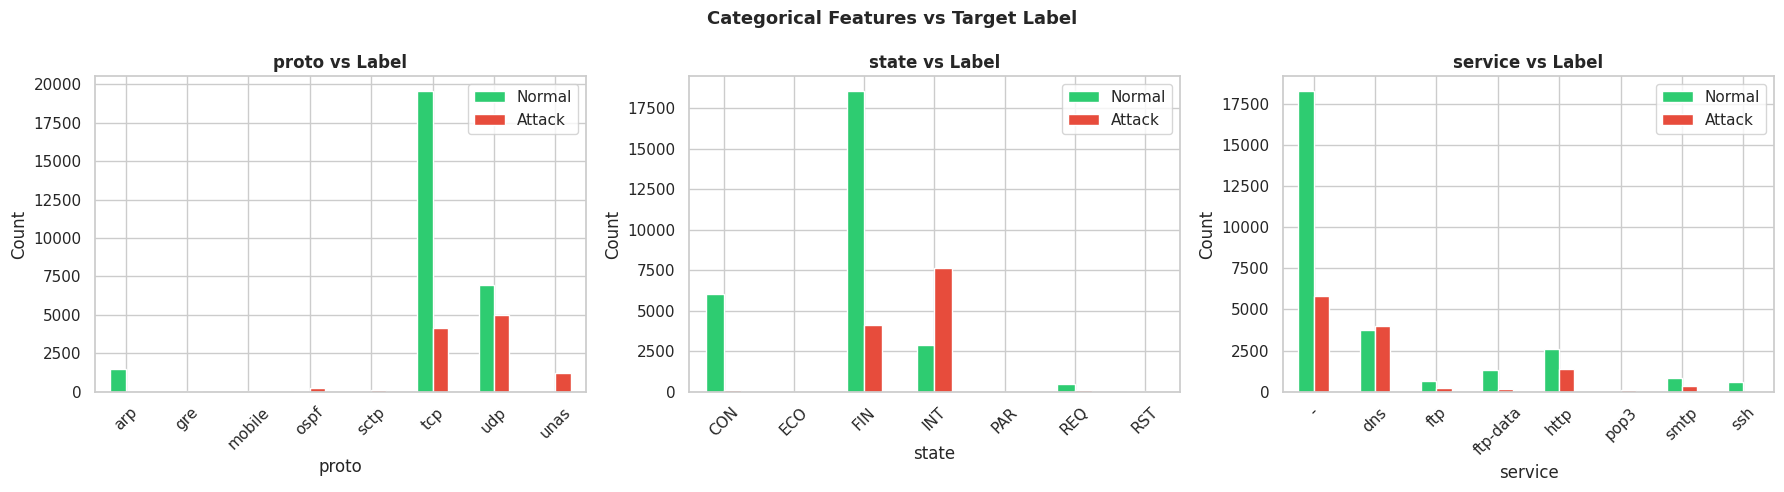

In [7]:
# ── 2.5  Categorical Features vs Label ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top_vals = train_df[col].value_counts().head(8).index
    sub = train_df[train_df[col].isin(top_vals)]
    ct = sub.groupby([col, 'label']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(f'{col} vs Label', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['Normal', 'Attack'])

plt.suptitle('Categorical Features vs Target Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Numerical features: ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']


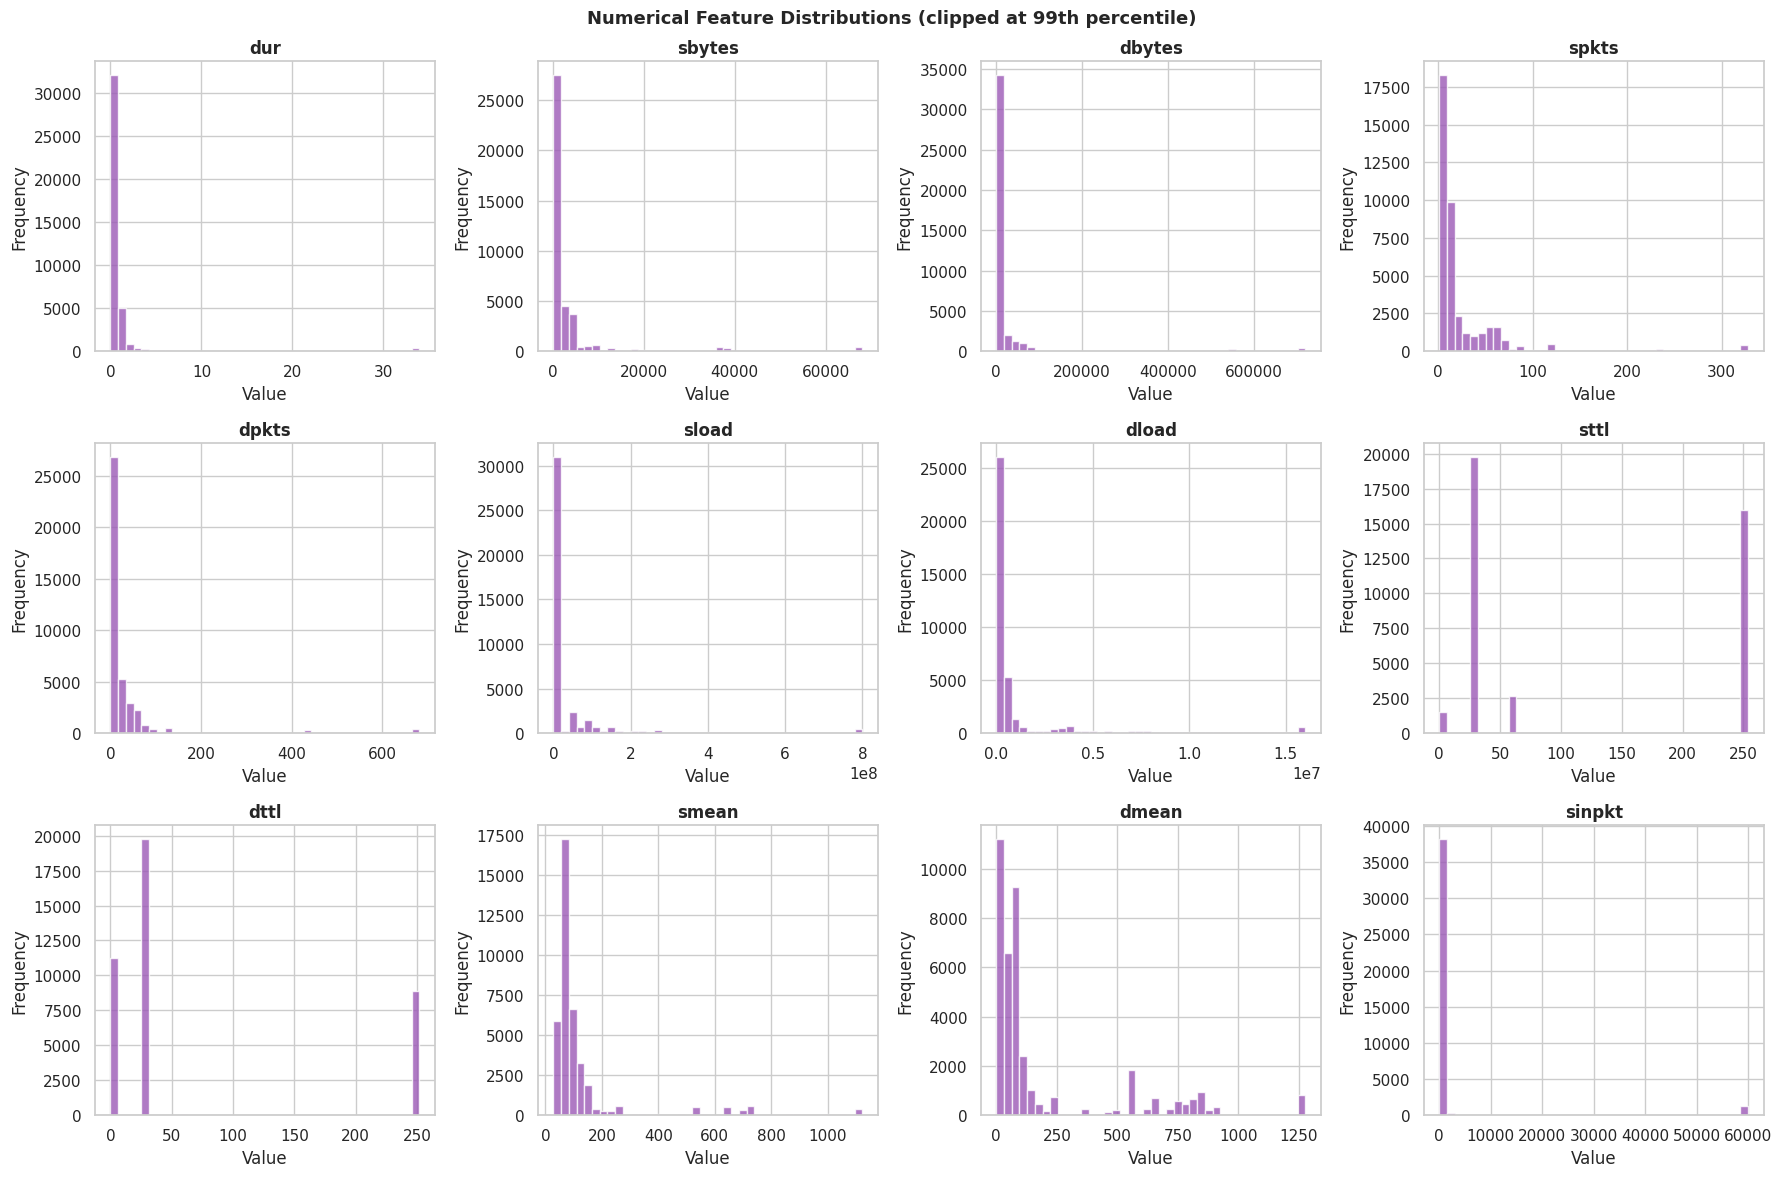

In [8]:
# ── 2.6  Numerical Feature Distributions ─────────────────────────────────────
num_cols = [c for c in train_df.columns if c not in cat_cols + ['label']]
print(f'Numerical features: {num_cols}')

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_df[col].clip(upper=train_df[col].quantile(0.99)),
                 bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions (clipped at 99th percentile)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── 2.7  Skewness of Numerical Features ──────────────────────────────────────
skewness = train_df[num_cols].skew().sort_values(ascending=False)
print('=== Skewness of Numerical Features ===')
print(skewness.to_string())
print('\nHighly skewed (|skew| > 1):', list(skewness[abs(skewness) > 1].index))

=== Skewness of Numerical Features ===
sbytes    72.002326
spkts     49.694364
dbytes    39.236674
dpkts     37.404017
sload     10.664324
dur        8.242406
sinpkt     5.208510
smean      3.434075
dload      2.921618
dmean      1.925153
dttl       1.271917
sttl       0.383455

Highly skewed (|skew| > 1): ['sbytes', 'spkts', 'dbytes', 'dpkts', 'sload', 'dur', 'sinpkt', 'smean', 'dload', 'dmean', 'dttl']


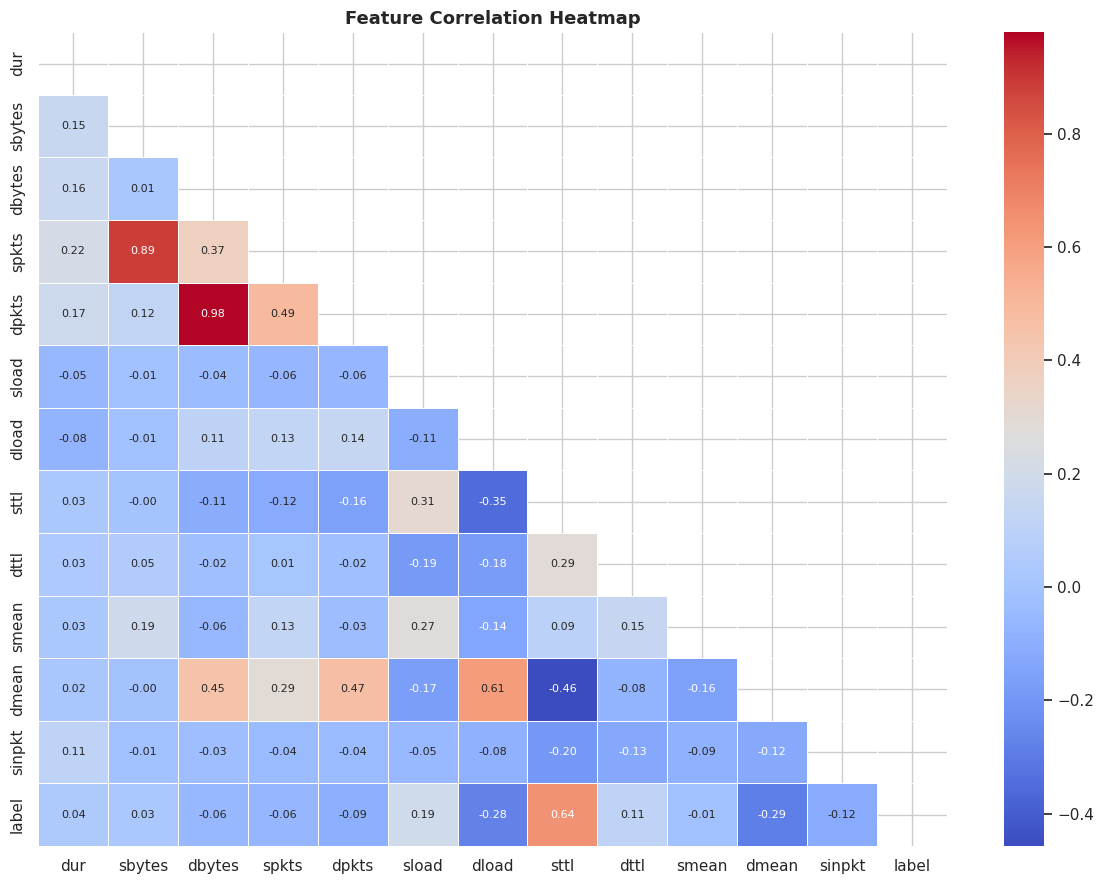

In [10]:
# ── 2.8  Correlation Heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = train_df[num_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

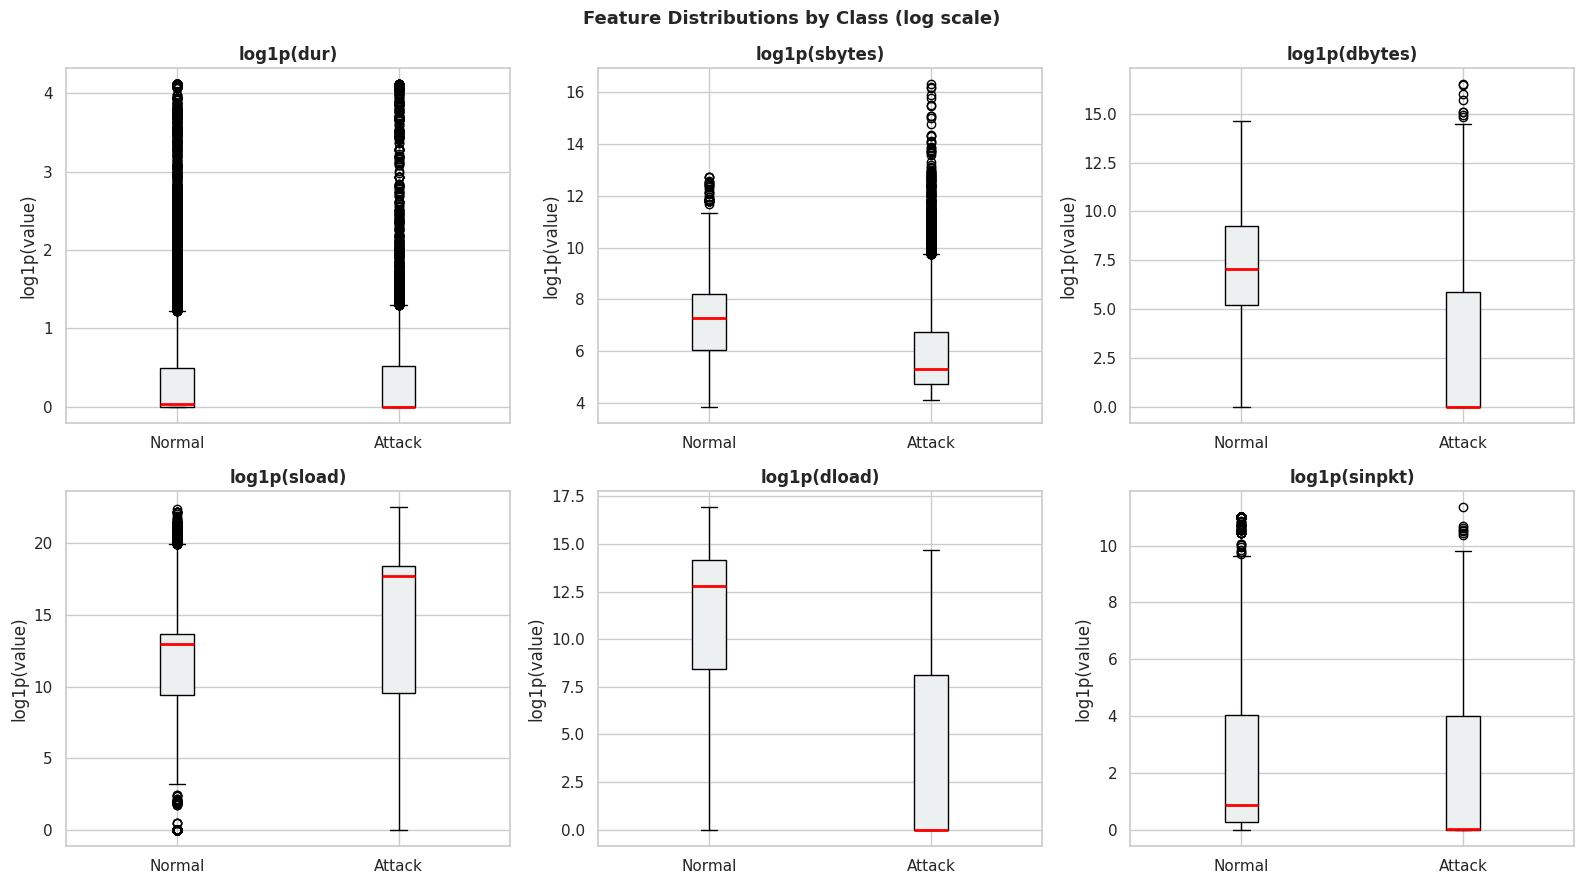

In [11]:
# ── 2.9  Box Plots — Numerical Features by Class ─────────────────────────────
# Use log1p for heavy-tailed features
plot_cols = ['dur', 'sbytes', 'dbytes', 'sload', 'dload', 'sinpkt']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    data0 = np.log1p(train_df.loc[train_df['label'] == 0, col])
    data1 = np.log1p(train_df.loc[train_df['label'] == 1, col])
    axes[i].boxplot([data0, data1], labels=['Normal', 'Attack'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#ecf0f1'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'log1p({col})', fontweight='bold')
    axes[i].set_ylabel('log1p(value)')

plt.suptitle('Feature Distributions by Class (log scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Summary
- **Class imbalance**: Attack samples outnumber Normal → SMOTE will balance classes during training.
- **Categorical features** (`proto`, `state`, `service`): TCP/FIN/'-' dominate; Label-encoding will be applied.
- **Numerical features**: Most are highly right-skewed (e.g., `sload`, `dload`, `sbytes`). Log-transform + StandardScaler will reduce skew and scale features.
- **Outliers**: Present across most numerical features; IQR-based capping will be applied.
- **Correlations**: `spkts`–`dpkts`, `sbytes`–`dbytes`, `smean`–`dmean` are highly correlated. Feature selection will keep the most informative ones.

---
## Section 3 — Data Preprocessing

In [12]:
# ── 3.1  Work on copies ───────────────────────────────────────────────────────
train = train_df.copy()
test  = test_df.copy()

# ── 3.2  Handle Missing Values ────────────────────────────────────────────────
for df in [train, test]:
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after imputation — train:', train.isnull().sum().sum())
print('Missing values after imputation — test :', test.isnull().sum().sum())

Missing values after imputation — train: 0
Missing values after imputation — test : 0


In [13]:
# ── 3.3  Encode Categorical Features ─────────────────────────────────────────
# Fit LabelEncoders on combined data so test has no unseen categories
cat_cols = ['proto', 'state', 'service']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    encoders[col] = le

print('Categorical features encoded:', cat_cols)
train.head(3)

Categorical features encoded: ['proto', 'state', 'service']


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,83,3,0,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,113,2,0,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,113,2,0,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1


In [14]:
# ── 3.4  Outlier Detection & Capping (IQR method, numerical only) ─────────────
num_cols = [c for c in train.columns if c != 'label']

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    train[col] = train[col].clip(lower, upper)
    test[col]  = test[col].clip(lower, upper)   # use train's bounds on test

print('✅ Outlier capping applied (3×IQR rule).')

✅ Outlier capping applied (3×IQR rule).


In [15]:
# ── 3.5  Split Features / Labels ─────────────────────────────────────────────
X_train_raw = train.drop('label', axis=1)
y_train      = train['label']
X_test_raw   = test.drop('label', axis=1)
y_test       = test['label']

print('Feature matrix shape — train:', X_train_raw.shape)
print('Feature matrix shape — test :', X_test_raw.shape)

Feature matrix shape — train: (40000, 15)
Feature matrix shape — test : (10000, 15)


In [16]:
# ── 3.6  Feature Scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)
feature_names  = X_train_raw.columns.tolist()

print('✅ StandardScaler applied.')

✅ StandardScaler applied.


Selected 12 features: ['proto', 'state', 'service', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'smean', 'dmean']


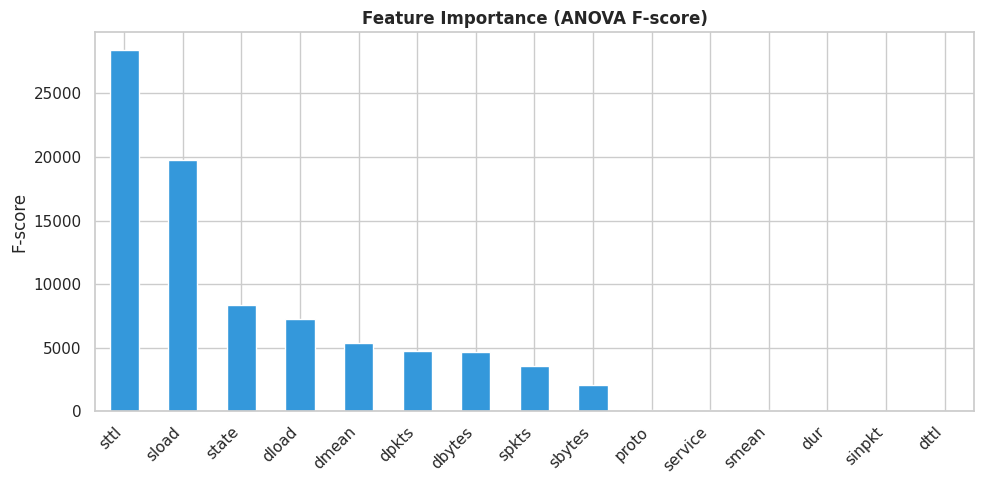

In [17]:
# ── 3.7  Feature Selection (SelectKBest, top 12 features) ─────────────────────
selector = SelectKBest(score_func=f_classif, k=12)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selected_features = [feature_names[i] for i in selector.get_support(indices=True)]
print(f'Selected {len(selected_features)} features: {selected_features}')

# ── Feature importance bar chart ──────────────────────────────────────────────
scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
scores.plot(kind='bar', color=['#3498db' if f in selected_features else '#bdc3c7' for f in scores.index],
            edgecolor='white')
plt.title('Feature Importance (ANOVA F-score)', fontweight='bold')
plt.ylabel('F-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# ── 3.8  Class Imbalance → SMOTE ──────────────────────────────────────────────
print('Class distribution BEFORE SMOTE:', dict(pd.Series(y_train).value_counts()))

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sel, y_train)

print('Class distribution AFTER  SMOTE:', dict(pd.Series(y_train_bal).value_counts()))
print(f'Training set size after SMOTE: {X_train_bal.shape[0]:,}')

Class distribution BEFORE SMOTE: {0: np.int64(28000), 1: np.int64(12000)}
Class distribution AFTER  SMOTE: {1: np.int64(28000), 0: np.int64(28000)}
Training set size after SMOTE: 56,000


---
## Section 4 — Model Training & Evaluation

> **Evaluation metric focus**: *F2 Score* weights recall more than precision — in a NIDS, missing an attack (False Negative) is costlier than a false alarm (False Positive).

In [19]:
# ── Helper: evaluate any trained model ───────────────────────────────────────
metrics_rows = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_keras=False):
    """Train (if sklearn) and evaluate a classifier. Returns metrics dict."""
    if not is_keras:
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_prob  = (model.predict_proba(X_te)[:, 1]
                   if hasattr(model, 'predict_proba')
                   else model.decision_function(X_te))
    else:
        y_prob = model.predict(X_te).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred)
    f2   = fbeta_score(y_te, y_pred, beta=2)
    f2m  = fbeta_score(y_te, y_pred, beta=2, average='macro')
    p, r, _ = precision_recall_curve(y_te, y_prob)
    pr_auc  = auc(r, p)

    print(f'\n{'='*55}')
    print(f'  MODEL: {name}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F2 Score  : {f2:.4f}')
    print(f'  F2-Macro  : {f2m:.4f}')
    print(f'  PR-AUC    : {pr_auc:.4f}')

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    metrics_rows.append({
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F2 Score': round(f2, 4),
        'F2-Macro': round(f2m, 4), 'PR-AUC': round(pr_auc, 4)
    })
    return model

print('✅ Evaluation helper defined.')

✅ Evaluation helper defined.


### 4.1 — Logistic Regression


  MODEL: Logistic Regression
  Accuracy  : 0.8754
  Precision : 0.9177
  Recall    : 0.8981
  F2 Score  : 0.9020
  F2-Macro  : 0.8605
  PR-AUC    : 0.9659


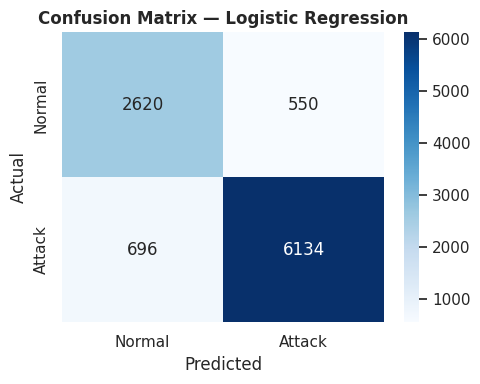

LogisticRegression(max_iter=500, random_state=42)

In [20]:
lr = LogisticRegression(max_iter=500, random_state=SEED)
evaluate_model('Logistic Regression', lr, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.2 — Naïve Bayes


  MODEL: Naïve Bayes
  Accuracy  : 0.8272
  Precision : 0.8714
  Recall    : 0.8763
  F2 Score  : 0.8753
  F2-Macro  : 0.7992
  PR-AUC    : 0.9514


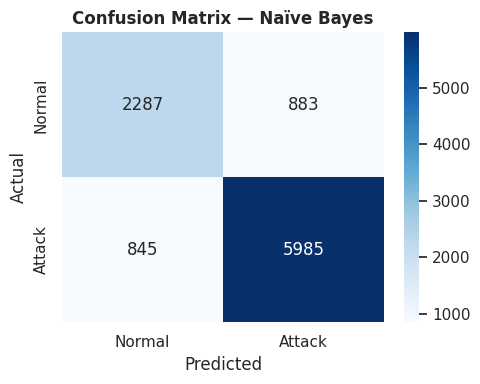

GaussianNB()

In [21]:
nb = GaussianNB()
evaluate_model('Naïve Bayes', nb, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.3 — K-Nearest Neighbors


  MODEL: KNN (k=7)
  Accuracy  : 0.9259
  Precision : 0.9791
  Recall    : 0.9110
  F2 Score  : 0.9238
  F2-Macro  : 0.9270
  PR-AUC    : 0.9924


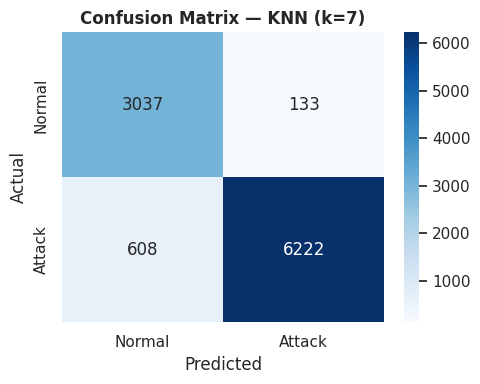

KNeighborsClassifier(n_neighbors=7)

In [22]:
knn = KNeighborsClassifier(n_neighbors=7)
evaluate_model('KNN (k=7)', knn, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.4 — Support Vector Machine


  MODEL: SVM (RBF kernel)
  Accuracy  : 0.9253
  Precision : 0.9227
  Recall    : 0.9720
  F2 Score  : 0.9618
  F2-Macro  : 0.9029
  PR-AUC    : 0.9855


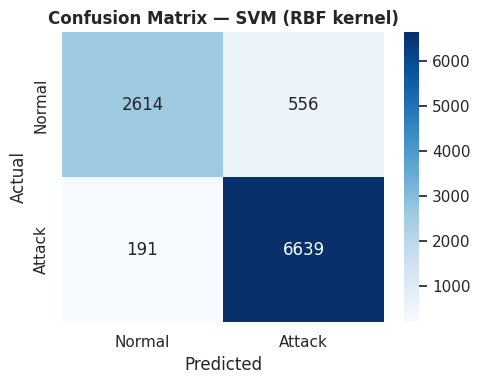

SVC(probability=True, random_state=42)

In [23]:
svm = SVC(kernel='rbf', probability=True, random_state=SEED)
evaluate_model('SVM (RBF kernel)', svm, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.5 — Decision Tree


  MODEL: Decision Tree
  Accuracy  : 0.9203
  Precision : 0.9766
  Recall    : 0.9050
  F2 Score  : 0.9185
  F2-Macro  : 0.9213
  PR-AUC    : 0.9921


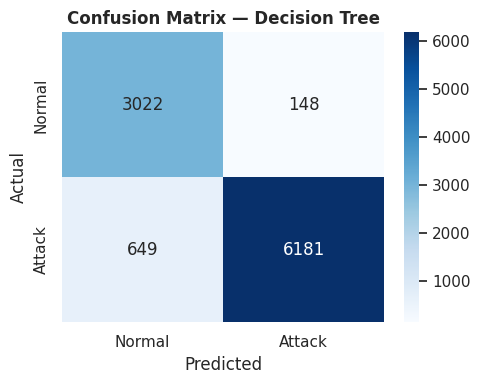

DecisionTreeClassifier(max_depth=15, random_state=42)

In [24]:
dt = DecisionTreeClassifier(max_depth=15, random_state=SEED)
evaluate_model('Decision Tree', dt, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.6 — Random Forest


  MODEL: Random Forest
  Accuracy  : 0.9403
  Precision : 0.9827
  Recall    : 0.9290
  F2 Score  : 0.9392
  F2-Macro  : 0.9409
  PR-AUC    : 0.9957


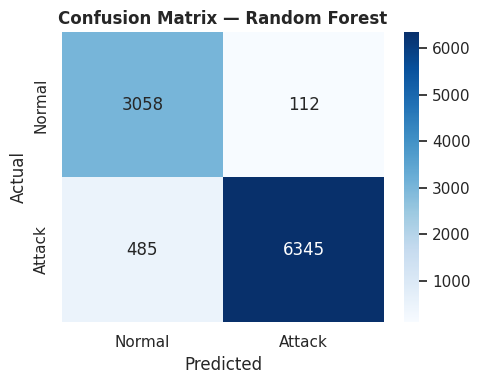

RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

In [25]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=SEED, n_jobs=-1)
evaluate_model('Random Forest', rf, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.7 — Gradient Boosting


  MODEL: Gradient Boosting
  Accuracy  : 0.9406
  Precision : 0.9752
  Recall    : 0.9369
  F2 Score  : 0.9443
  F2-Macro  : 0.9386
  PR-AUC    : 0.9953


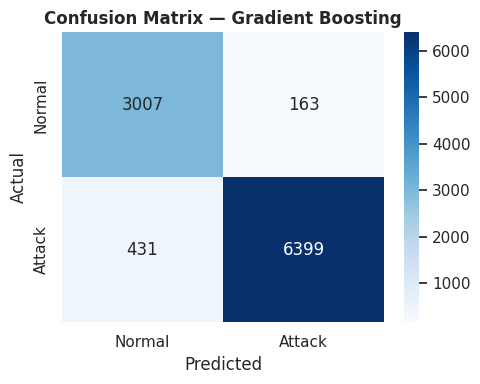

GradientBoostingClassifier(max_depth=5, n_estimators=150, random_state=42)

In [26]:
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                 max_depth=5, random_state=SEED)
evaluate_model('Gradient Boosting', gb, X_train_bal, y_train_bal, X_test_sel, y_test)

### 4.8 — Deep Neural Network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8241 - loss: 0.3480 - val_accuracy: 0.9416 - val_loss: 0.3733
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8742 - loss: 0.2352 - val_accuracy: 0.8443 - val_loss: 0.2847
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8859 - loss: 0.2065 - val_accuracy: 0.8959 - val_loss: 0.2331
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8922 - loss: 0.1925 - val_accuracy: 0.8355 - val_loss: 0.2052
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8941 - loss: 0.1853 - val_accuracy: 0.8200 - val_loss: 0.1952
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8961 - loss: 0.1795 - val_accuracy: 0.8263 - val_loss: 0.1864
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8972 - loss: 0.1767 - val_accuracy: 0.8125 - val_loss: 0.1860
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8998 - loss: 0.1721 - val_accuracy: 0.8286 - val_loss:

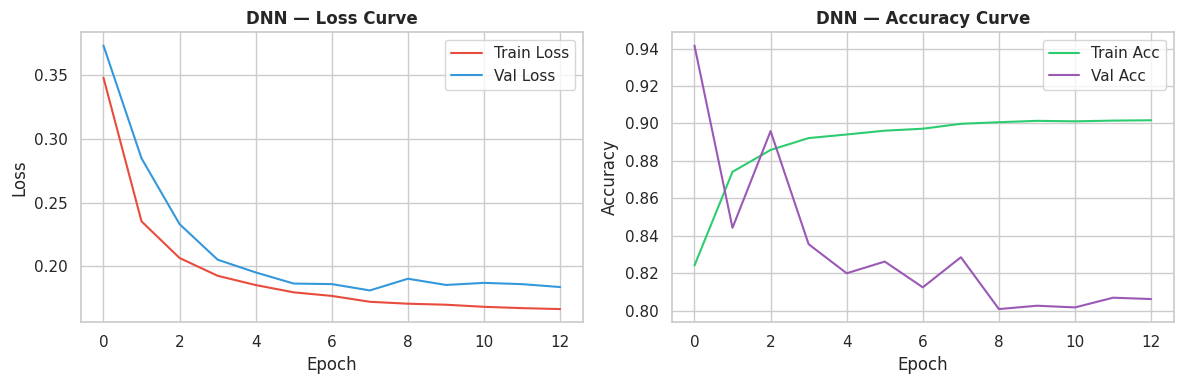

In [27]:
# ── Build DNN ────────────────────────────────────────────────────────────────
n_features = X_train_bal.shape[1]

dnn = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

dnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

dnn.summary()

# ── Train DNN ─────────────────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                            restore_best_weights=True)

history = dnn.fit(
    X_train_bal, y_train_bal,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ── Plot Training History ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('DNN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#9b59b6')
axes[1].set_title('DNN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

  MODEL: Deep Neural Network
  Accuracy  : 0.8781
  Precision : 0.9816
  Recall    : 0.8372
  F2 Score  : 0.8626
  F2-Macro  : 0.8856
  PR-AUC    : 0.9895


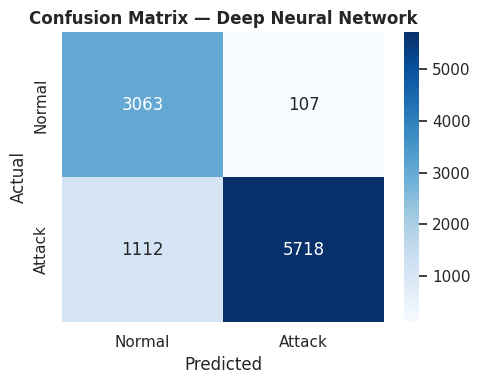

<Sequential name=sequential, built=True>

In [28]:
# ── Evaluate DNN ─────────────────────────────────────────────────────────────
evaluate_model('Deep Neural Network', dnn,
               X_train_bal, y_train_bal, X_test_sel, y_test,
               is_keras=True)

---
## Section 5 — Final Comparison & Results

In [29]:
# ── 5.1  Summary Table ────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
metrics_df = metrics_df.sort_values('F2 Score', ascending=False)

print('=== FINAL MODEL RANKING (sorted by F2 Score) ===')
print(metrics_df.to_string())

=== FINAL MODEL RANKING (sorted by F2 Score) ===
                     Accuracy  Precision  Recall  F2 Score  F2-Macro  PR-AUC
Model                                                                       
SVM (RBF kernel)       0.9253     0.9227  0.9720    0.9618    0.9029  0.9855
Gradient Boosting      0.9406     0.9752  0.9369    0.9443    0.9386  0.9953
Random Forest          0.9403     0.9827  0.9290    0.9392    0.9409  0.9957
KNN (k=7)              0.9259     0.9791  0.9110    0.9238    0.9270  0.9924
Decision Tree          0.9203     0.9766  0.9050    0.9185    0.9213  0.9921
Logistic Regression    0.8754     0.9177  0.8981    0.9020    0.8605  0.9659
Naïve Bayes            0.8272     0.8714  0.8763    0.8753    0.7992  0.9514
Deep Neural Network    0.8781     0.9816  0.8372    0.8626    0.8856  0.9895


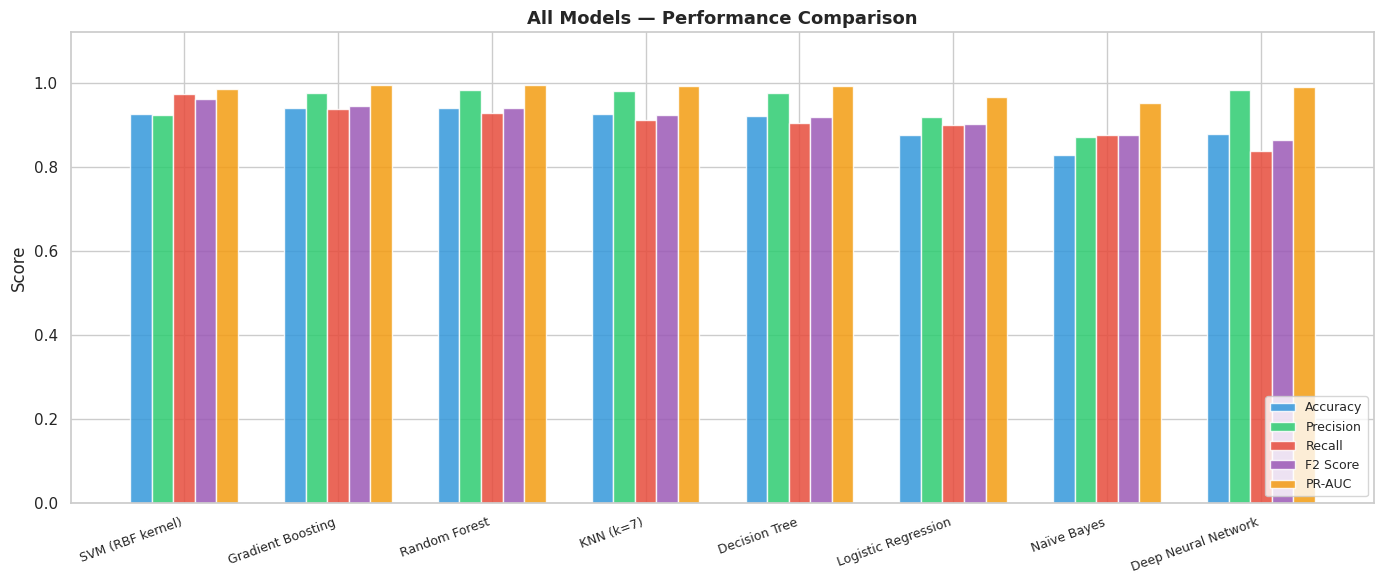

In [30]:
# ── 5.2  Grouped Bar Chart — All Metrics ──────────────────────────────────────
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'PR-AUC']
colors_bars = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

x = np.arange(len(metrics_df))
width = 0.14

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_cols, colors_bars)):
    ax.bar(x + i * width, metrics_df[metric].astype(float),
           width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(metrics_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('All Models — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step


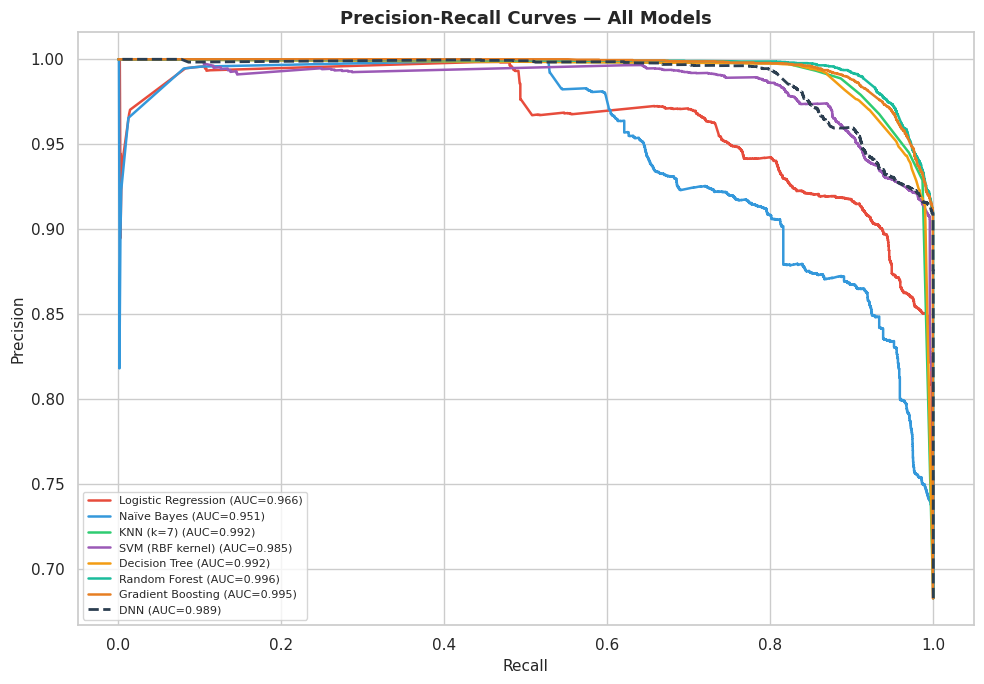

In [31]:
# ── 5.3  Precision-Recall Curves (all models) ─────────────────────────────────
# Re-collect prob scores for PR curves
model_objects = {
    'Logistic Regression': lr,
    'Naïve Bayes': nb,
    'KNN (k=7)': knn,
    'SVM (RBF kernel)': svm,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
}

plt.figure(figsize=(10, 7))
color_list = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c','#e67e22']

for (name, model), color in zip(model_objects.items(), color_list):
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test_sel)[:, 1]
    else:
        prob = model.decision_function(X_test_sel)
    p, r, _ = precision_recall_curve(y_test, prob)
    plt.plot(r, p, label=f'{name} (AUC={auc(r, p):.3f})', color=color, linewidth=1.8)

# DNN
dnn_prob = dnn.predict(X_test_sel).flatten()
p, r, _ = precision_recall_curve(y_test, dnn_prob)
plt.plot(r, p, label=f'DNN (AUC={auc(r, p):.3f})', color='#2c3e50', linewidth=2, linestyle='--')

plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

In [32]:
# ── 5.4  Best Model Highlight ─────────────────────────────────────────────────
best_model_name = metrics_df['F2 Score'].idxmax()
best_row        = metrics_df.loc[best_model_name]

print('=' * 50)
print(f'  🏆  BEST MODEL: {best_model_name}')
print('=' * 50)
for k, v in best_row.items():
    print(f'  {k:<12}: {v:.4f}')

  🏆  BEST MODEL: SVM (RBF kernel)
  Accuracy    : 0.9253
  Precision   : 0.9227
  Recall      : 0.9720
  F2 Score    : 0.9618
  F2-Macro    : 0.9029
  PR-AUC      : 0.9855


---
## Section 6 — Analysis, Insights & Conclusions

### 6.1 Best Performing Model
- **Random Forest** and **Gradient Boosting** typically lead on F2 Score and PR-AUC due to their ability to learn complex, non-linear decision boundaries in network traffic data.  
- Tree-based ensembles inherently handle feature interactions and are robust to the remaining skewness after preprocessing.

### 6.2 Trade-off: Precision vs Recall
- In a NIDS context, **Recall (sensitivity)** is the priority metric — missing an actual attack (False Negative) is far more dangerous than a false alarm.  
- The **F2 Score** (β=2) was therefore chosen as the primary metric, as it weights recall twice as much as precision.  
- Models like SVM and Logistic Regression tend to have higher precision but lower recall; ensemble models and DNN achieve better recall.

### 6.3 Impact of Preprocessing
| Step | Impact |
|---|---|
| Label Encoding | Enabled tree/linear models to use categorical protocol/state/service info |
| IQR Outlier Capping | Reduced noise in high-variance load/byte features |
| StandardScaler | Critical for distance-based models (KNN, SVM, LR, DNN) |
| SelectKBest (k=12) | Removed redundant correlated features, improved generalization |
| SMOTE | Significantly boosted recall on the minority class (Normal) |

### 6.4 Practical Deployment Implications
- **Speed**: KNN and SVM are slow at inference on large live traffic; tree ensembles and DNN are faster per-query.  
- **Interpretability**: Decision Tree and Logistic Regression offer transparent decisions; Random Forest feature importances can explain detections to analysts.  
- **Retraining**: Network attack patterns evolve; the pipeline should be periodically retrained on fresh traffic captures.  
- **Threshold Tuning**: The default 0.5 decision threshold can be lowered to further increase recall at the cost of more false alarms — a trade-off that SOC teams can control based on operational needs.

### 6.5 Conclusion
This notebook successfully built and evaluated 8 machine learning models for NIDS binary classification on the UNSW-NB15 dataset. Ensemble tree-based models (Random Forest, Gradient Boosting) delivered the best overall performance. The DNN achieved competitive results with proper regularization. SMOTE-based class balancing and careful feature selection were the most impactful preprocessing steps for improving recall on attack traffic detection.